In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sfreq = 32
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.5, fmax=16)
dataset = BNCI2014008()
#dataset = EPFLP300()


In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.656 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


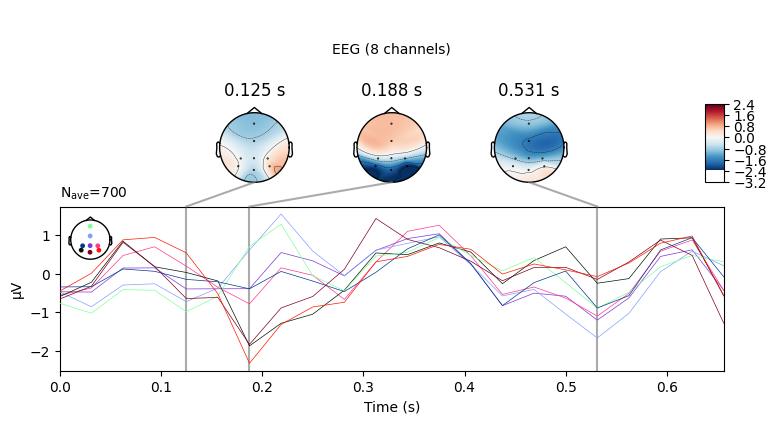

No projector specified for this dataset. Please consider the method self.add_proj.


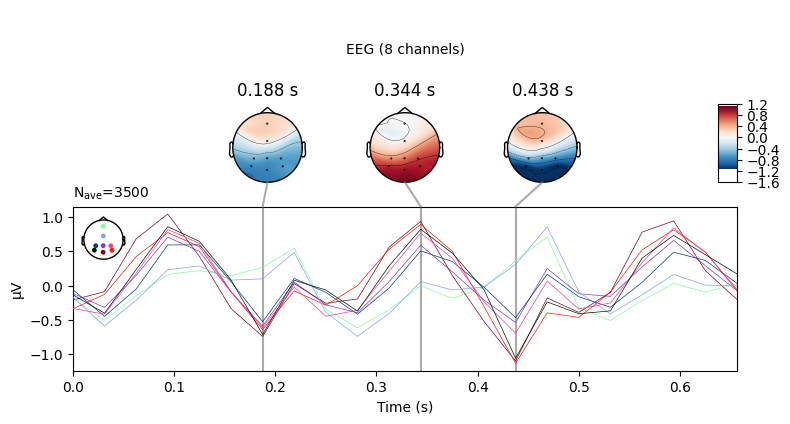

No projector specified for this dataset. Please consider the method self.add_proj.


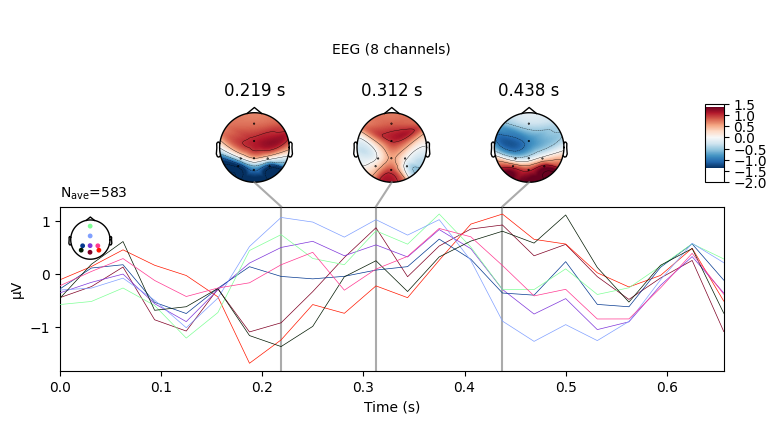

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint()
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
tmin = epochs.tmin
sfreq = epochs.info['sfreq']

def lagged_tensor(X, y=None):    
    window = 0.2
    max_lag = 0.5
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.hoda import MLSVD
from mne.decoding import Scaler

X = epochs.get_data(picks='eeg')
split = len(epochs)//2
X_train = X[:split]
X_test = X[split:]
y_train = labels[:split]
y_test = labels[split:]


scaler = Scaler(scalings='mean', with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = lagged_tensor(X_train)
X_test = lagged_tensor(X_test)

tl.set_backend('numpy')


#mlsvd = MLSVD(modes=(0,), rank=(16,))
#X_train = mlsvd.fit_transform(X_train)
#X_test = mlsvd.transform(X_test)
#factors = mlsvd.factors_
factors = [np.eye(X_train.shape[1+k]) for k in range(len(X_train.shape[1:]))]

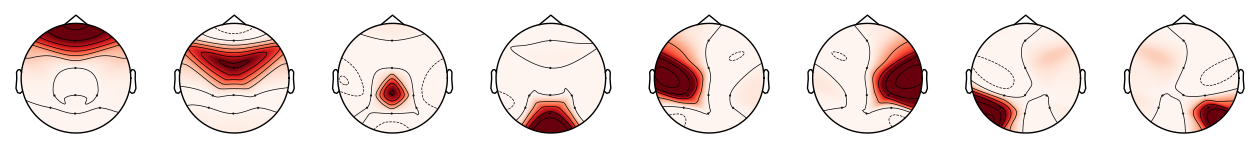

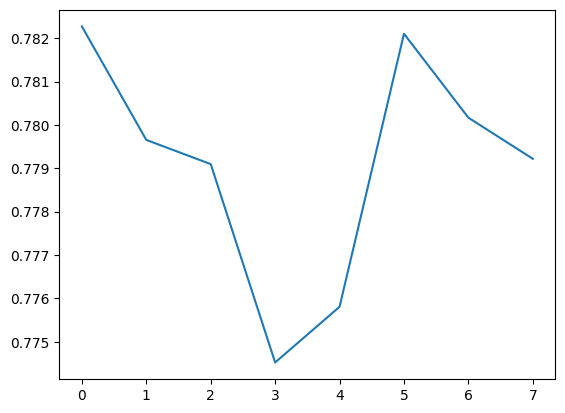

In [8]:
fig, axs = plt.subplots(1, X_train.shape[1], figsize=(16,6))
for i in range(X_train.shape[1]):
    w = factors[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
plt.show()
plt.plot(np.abs(X_train).mean(axis=(0,2,3)))

In [23]:
hoda = HODA(max_iter=128, rank=5, tol=1e-6,
            initialize ='svd', verbose=True,
            shrinkage='oas', toeplitz=(1,2), solver='ratio-gevd')
#%lprun -f hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0012  shrinkage=0.0034  shrinkage=0.0147  step=3.2767e+00
[1/128]  shrinkage=0.0016  shrinkage=0.0036  shrinkage=0.0215  step=3.0410e+00
[2/128]  shrinkage=0.0015  shrinkage=0.0106  shrinkage=0.0189  step=2.5164e+00
[3/128]  shrinkage=0.0016  shrinkage=0.0049  shrinkage=0.0618  step=1.1937e+00
[4/128]  shrinkage=0.0016  shrinkage=0.0059  shrinkage=0.0366  step=7.3958e-01
[5/128]  shrinkage=0.0016  shrinkage=0.0062  shrinkage=0.0455  step=9.4952e-01
[6/128]  shrinkage=0.0016  shrinkage=0.0066  shrinkage=0.0275  step=9.5334e-01
[7/128]  shrinkage=0.0016  shrinkage=0.0067  shrinkage=0.0301  step=8.3233e-01
[8/128]  shrinkage=0.0016  shrinkage=0.0068  shrinkage=0.0251  step=2.5481e-01
[9/128]  shrinkage=0.0016  shrinkage=0.0069  shrinkage=0.0254  step=9.4796e-02
[10/128]  shrinkage=0.0016  shrinkage=0.0069  shrinkage=0.0243  step=8.6910e-02
[11/128]  shrinkage=0.0016  shrinkage=0.0070  shrinkage=0.0244  step=3.5489e-02
[12/128]  shrinkage=0.0016  shrinkage=0.0070  shri

[102/128]  shrinkage=0.0016  shrinkage=0.0073  shrinkage=0.0233  step=2.0031e+00
[103/128]  shrinkage=0.0016  shrinkage=0.0060  shrinkage=0.0279  step=2.0031e+00
[104/128]  shrinkage=0.0016  shrinkage=0.0073  shrinkage=0.0233  step=2.0031e+00
[105/128]  shrinkage=0.0016  shrinkage=0.0060  shrinkage=0.0279  step=2.0031e+00
[106/128]  shrinkage=0.0016  shrinkage=0.0073  shrinkage=0.0233  step=2.0030e+00
[107/128]  shrinkage=0.0016  shrinkage=0.0060  shrinkage=0.0279  step=2.0030e+00
[108/128]  shrinkage=0.0016  shrinkage=0.0073  shrinkage=0.0233  step=2.0030e+00
[109/128]  shrinkage=0.0016  shrinkage=0.0060  shrinkage=0.0279  step=2.0030e+00
[110/128]  shrinkage=0.0016  shrinkage=0.0073  shrinkage=0.0233  step=2.0030e+00
[111/128]  shrinkage=0.0016  shrinkage=0.0060  shrinkage=0.0279  step=2.0030e+00
[112/128]  shrinkage=0.0016  shrinkage=0.0073  shrinkage=0.0233  step=2.0030e+00
[113/128]  shrinkage=0.0016  shrinkage=0.0060  shrinkage=0.0279  step=2.0030e+00
[114/128]  shrinkage=0.0016 

HODA(initialize='svd', max_iter=128, rank=5, solver='ratio-gevd',
     toeplitz=(1, 2), tol=1e-06, verbose=True)

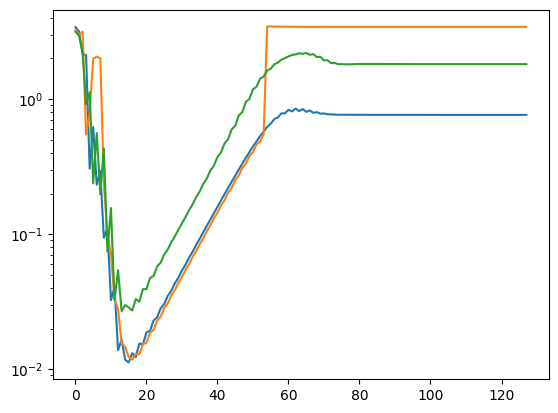

In [24]:
import cupy
plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

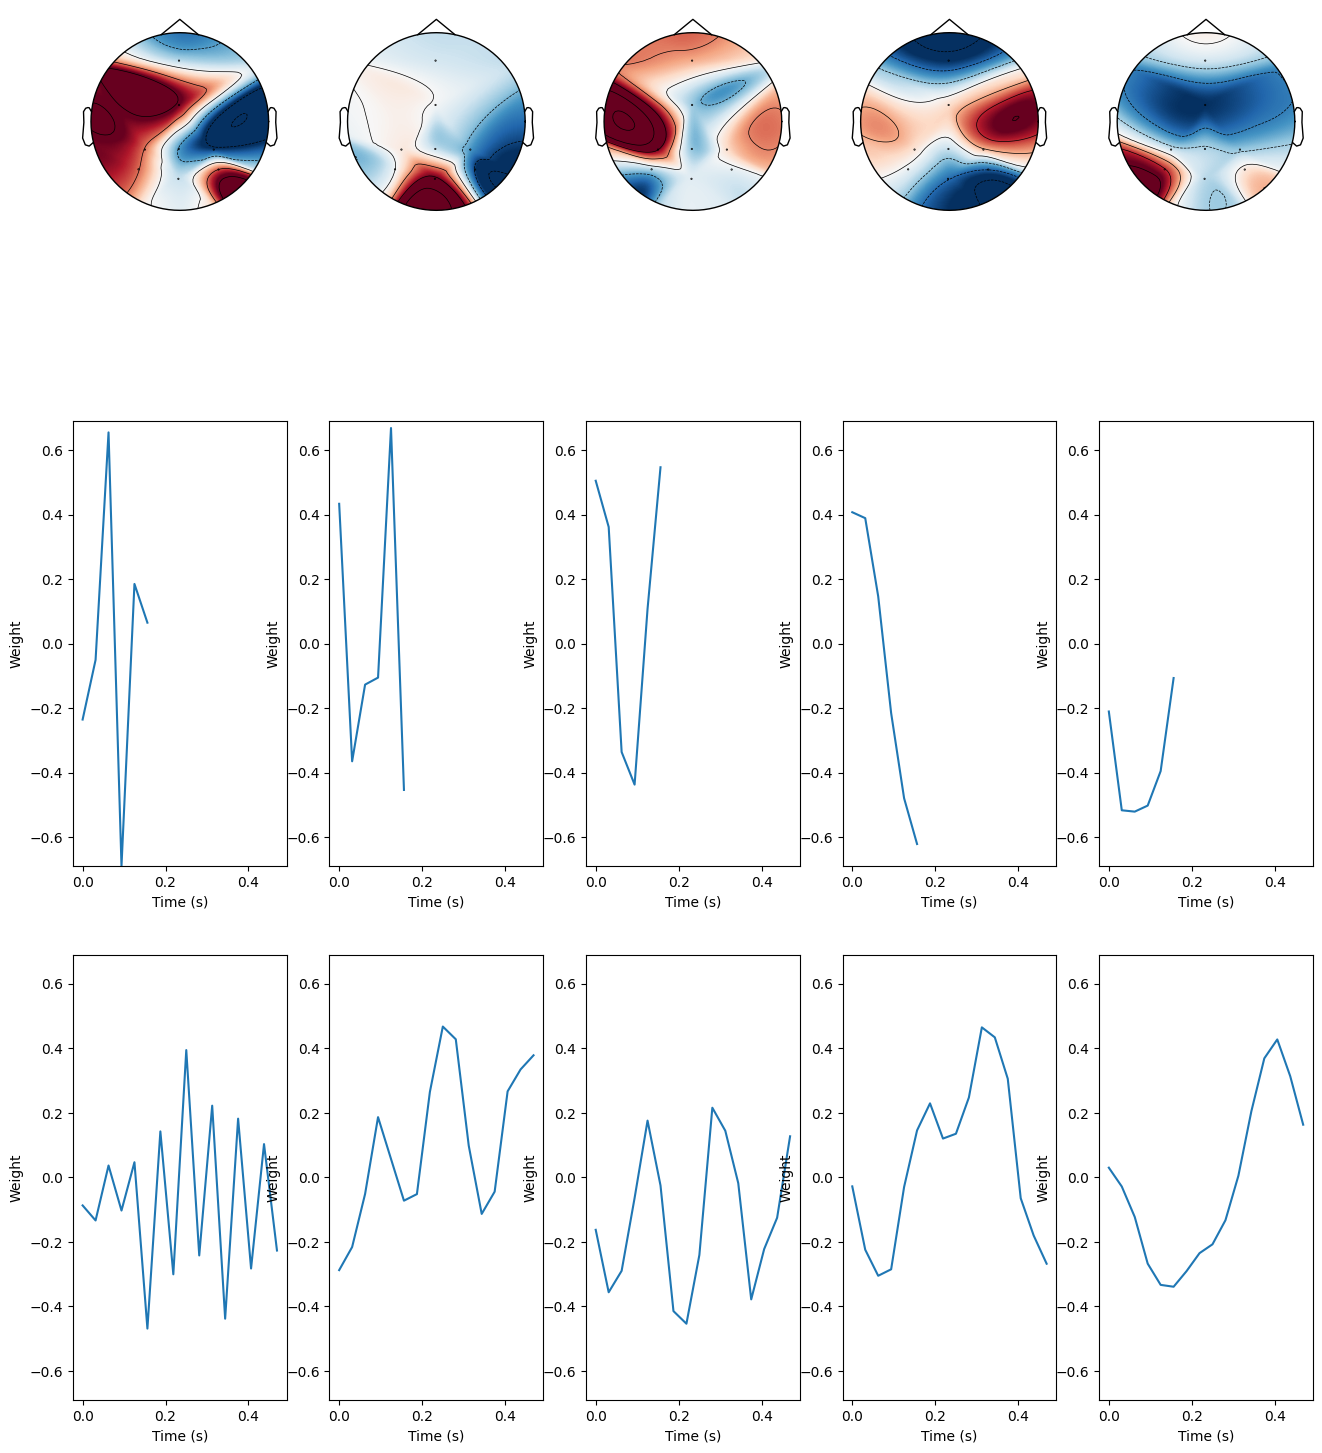

In [25]:

fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
projs = [cupy.asnumpy(factors[k] @ p) for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank):
    w = projs[1][:,i]
    axs[1,i].plot(epochs.times[:len(w)], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
    axs[1,i].sharex(axs[2,0])
    axs[1,i].sharey(axs[2,0])
for i in range(hoda.rank):
    w = cupy.asnumpy(projs[2][:,i])
    axs[2,i].plot(epochs.times[:len(w)], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
    axs[2,i].sharex(axs[2,0])
    axs[2,i].sharey(axs[2,0])


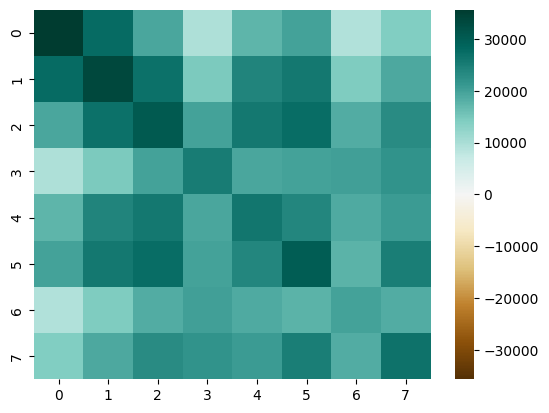

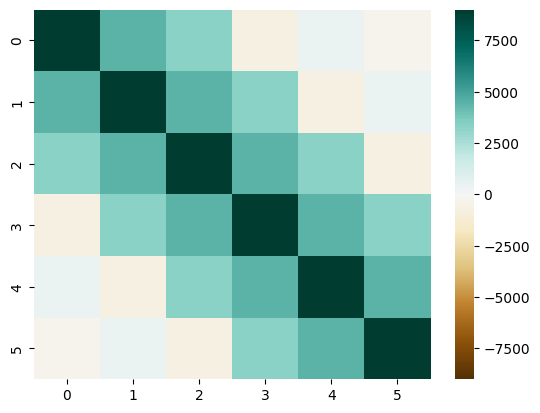

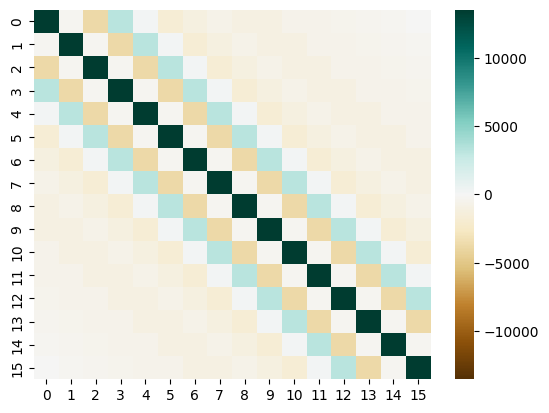

In [26]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

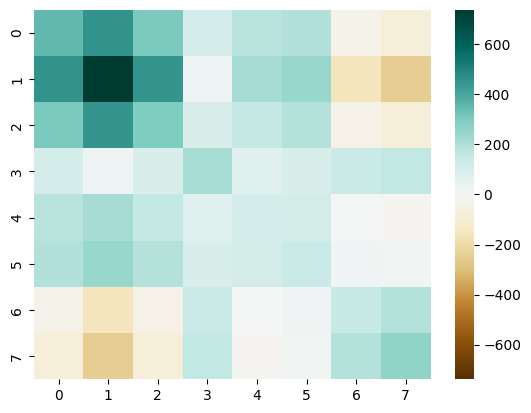

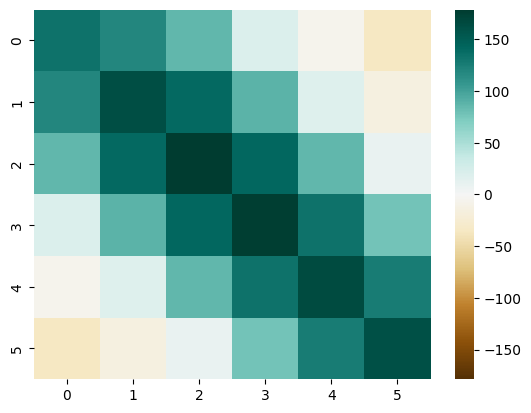

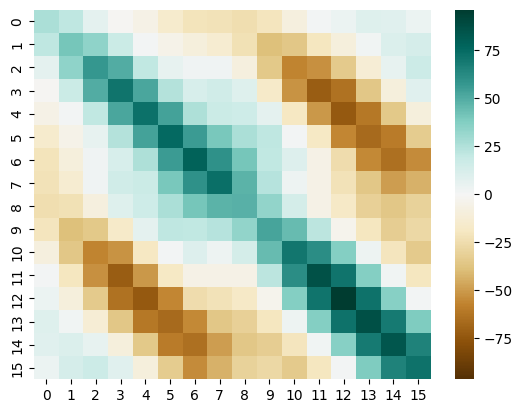

In [27]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

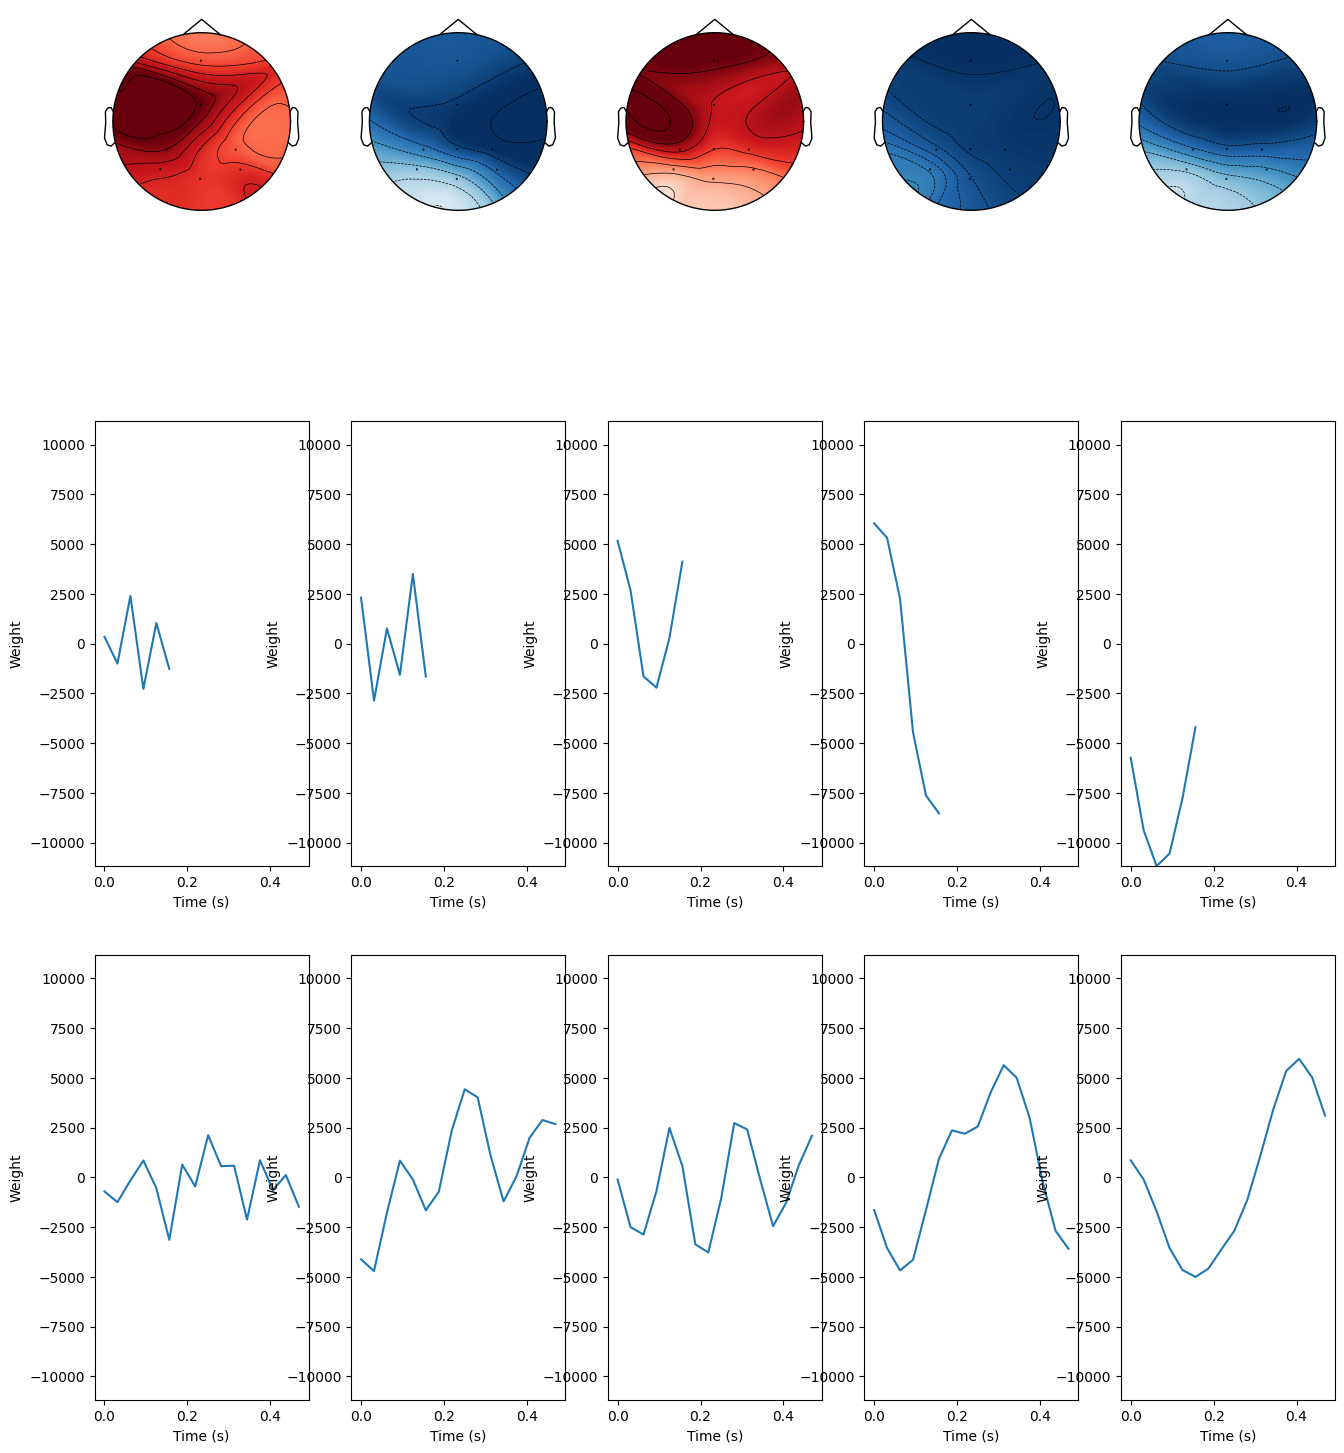

In [32]:
fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
aps = [cupy.asnumpy(factors[k] @ hoda.scatter_w_[k] @ p) for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank):
    w = aps[1][:,i]
    axs[1,i].plot(epochs.times[:len(w)], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
    axs[1,i].sharex(axs[2,0])
    axs[1,i].sharey(axs[2,0])

for i in range(hoda.rank):
    w = aps[2][:,i]
    axs[2,i].plot(epochs.times[:len(w)], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
    axs[2,i].sharex(axs[2,0])
    axs[2,i].sharey(axs[2,0])

In [33]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))
print(Xt_train.shape)
print(Xt_test.shape)

(2100, 125)
(2100, 125)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

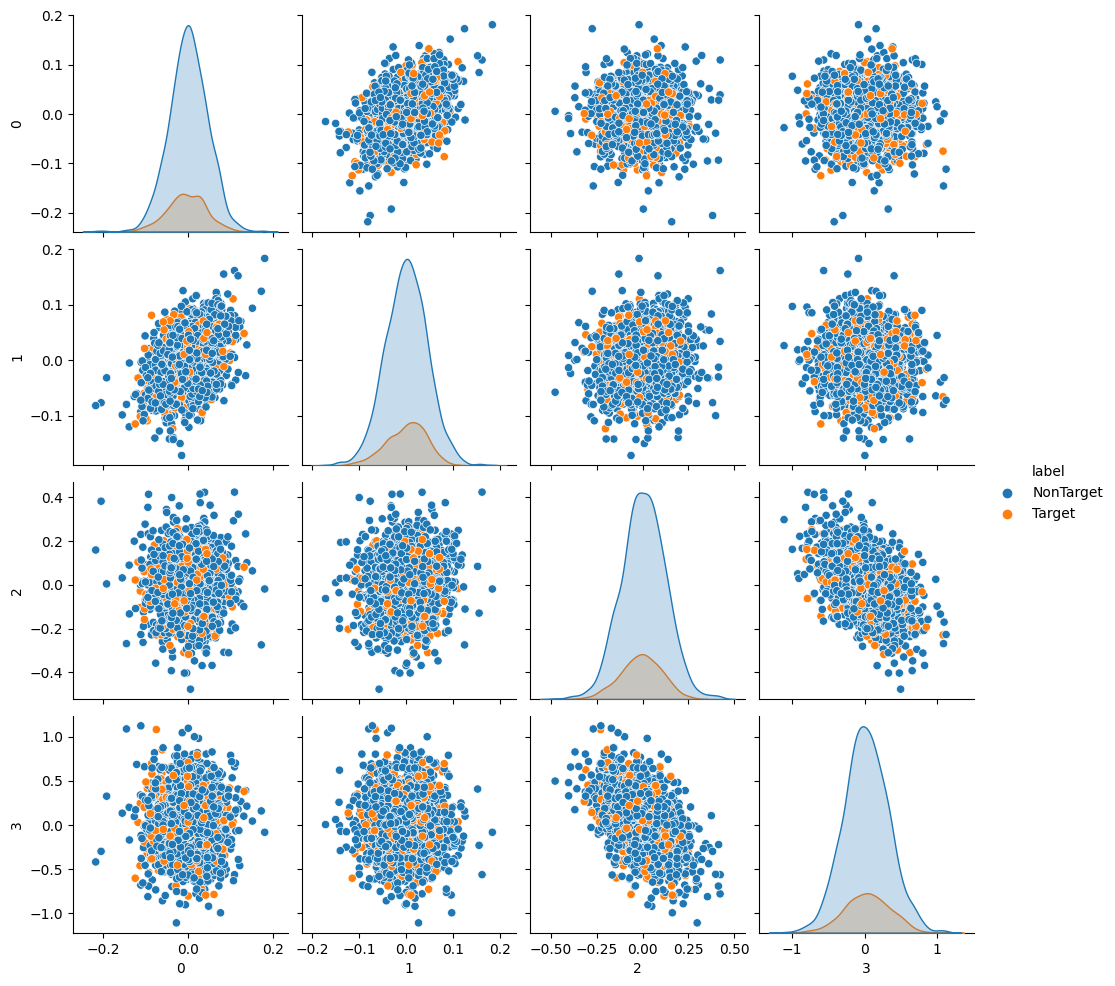

In [35]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [36]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.8812604081632653

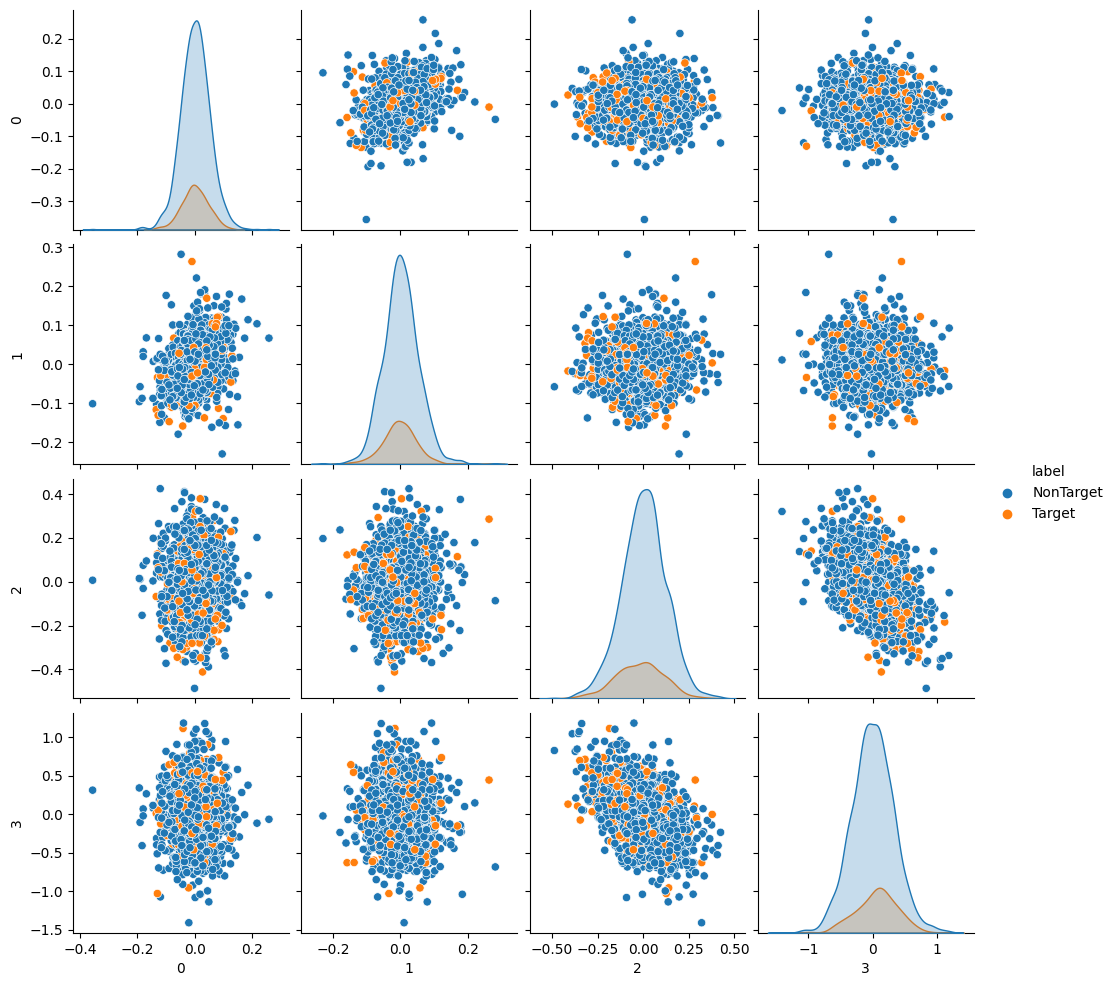

In [37]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [38]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.8406416326530612